In [12]:
import jax
from jax import config
import jax.numpy as jnp
config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")

import os
import jaxley as jx
from jaxley_mech.channels.benison01 import Na, Leak, KA, KCa, Kdr, CaL, CaN, CaNernstReversal,CaPumpNS 

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import matplotlib.pyplot as plt
import seaborn as sns
from utils.stim_utils import generate_1_f_noise, plot_stim
from utils.cells import LN_cell, softplus
from utils.utils import upsample_hold
plt.rcParams["figure.dpi"] = 100
from utils.training_utils import K_func, ln_forward, current_map
from utils.rgc import build_cell, simulate_with_current, rgc_forward
from utils.utils import upsample_hold_edges, voltage_batch_to_mu, make_edges

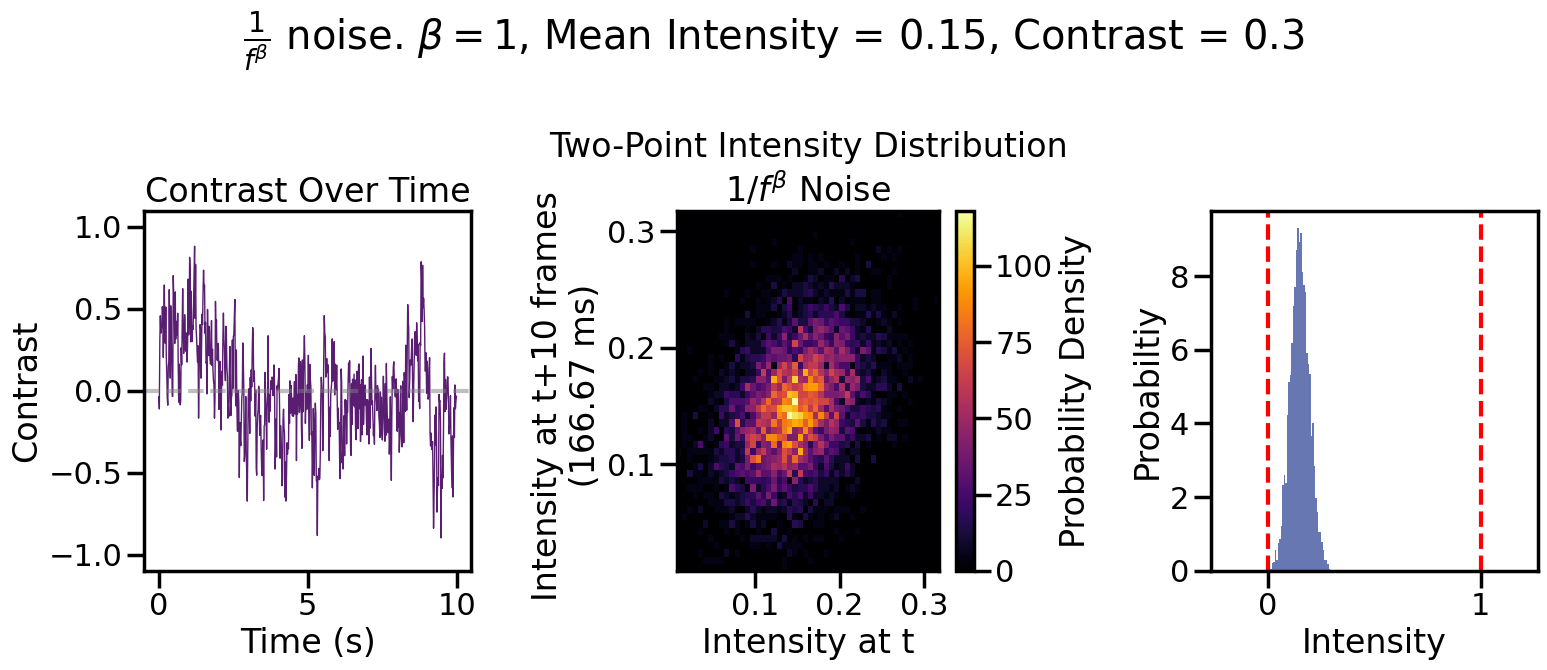

In [13]:
beta= 1
mean_intensity = 0.15
desired_contrast = 0.3
stim_duration = 10
trials = 10
frame_rate = 60
frame_dwell = 1
tau = 10

all_noise = []
all_contrast = []
for trial in range(trials):
    noise, contrast = generate_1_f_noise(
        beta, frame_rate * stim_duration, frame_rate,
        frame_dwell, mean_intensity, desired_contrast,
        noise_seed=trial)        
    all_noise.append(noise)
    all_contrast.append(contrast)

noise_t = jnp.concatenate(all_noise)
contrast_t = jnp.concatenate(all_contrast)
stim = jnp.array(all_contrast)

plot_stim(noise_t=noise_t, contrast_mat=stim, 
          beta=beta,
          mean_intensity=mean_intensity, 
          desired_contrast=desired_contrast, 
          tau=10, frame_rate=60, figsize=(16,7))

In [14]:
def init_ln_params(key, 
                   alpha_j0=0.16, 
                   alpha_h0=0.38, 
                   logit_tau10=0.55, 
                   logit_tau20=-0.57,
                   beta0=2.3, 
                   shift0=0.304, 
                   noise=0.02,
                   DC=0.05, 
                   scale = 0.053):
    
    k1, k2, k3, k4 = jax.random.split(key, 4)
    return {
        "logit_tau1": jnp.array(logit_tau10, dtype=jnp.float32) + noise * jax.random.normal(k1, ()),
        "logit_tau2": jnp.array(logit_tau20, dtype=jnp.float32) + noise * jax.random.normal(k2, ()),
        "alpha_j":    jnp.array(alpha_j0,    dtype=jnp.float32) + noise * jax.random.normal(k3, ()),
        "alpha_h":    jnp.array(alpha_h0,    dtype=jnp.float32) + noise * jax.random.normal(k4, ()),

        "log_beta":   jnp.log(jnp.array(beta0, dtype=jnp.float32)),
        "shift":      jnp.array(shift0,       dtype=jnp.float32),
        ### Current params
        "DC" :      jnp.array(DC, dtype=jnp.float32),
        "scale":    jnp.array(scale, dtype=jnp.float32)
    }


In [ ]:
import matplotlib.cm as cm
cmap = cm.viridis
frame_rate = 60
dt_stim = 1/frame_rate
dt_cell = 0.02e-3                  # seconds
dt_cell_ms = 0.02
key = jax.random.PRNGKey(0)
params_ln = init_ln_params(key)


filt_dur = 0.6

K_T = int(round(filt_dur / float(dt_stim)))
max_tau = jnp.array(((K_T - 1) / 3.0) * float(dt_stim), dtype=jnp.float32)
drive, L, K =  ln_forward(params_ln, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)


In [ ]:
I_frame = current_map(drive, params_ln)
T_f = I_frame.shape[-1]              # number of frames
T_cell = int(round(T_f * dt_stim / dt_cell))
I_syn = upsample_hold_edges(I_frame, dt_stim=dt_stim, dt_cell=dt_cell, T_cell=T_cell)


In [18]:
# Build cell
cell0 = build_cell()
cell0.delete_recordings()
cell0.record("v")
V_batch = rgc_forward(I_syn, dt_cell_ms, cell0)  # dt_cell_ms should be in the same units integrate expects
print(V_batch.shape)

Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.


/home/guardomayas/miniforge3/envs/jaxley/lib/python3.12/site-packages/jaxley/modules/base.py:904: UserWarning: This method is experimental, use at your own risk.
  warnings.warn("This method is experimental, use at your own risk.")


(10, 500000)


/tmp/ipykernel_52891/3127388900.py:34: UserWarning: The figure layout has changed to tight
  fig.tight_layout(w_pad=0.1)


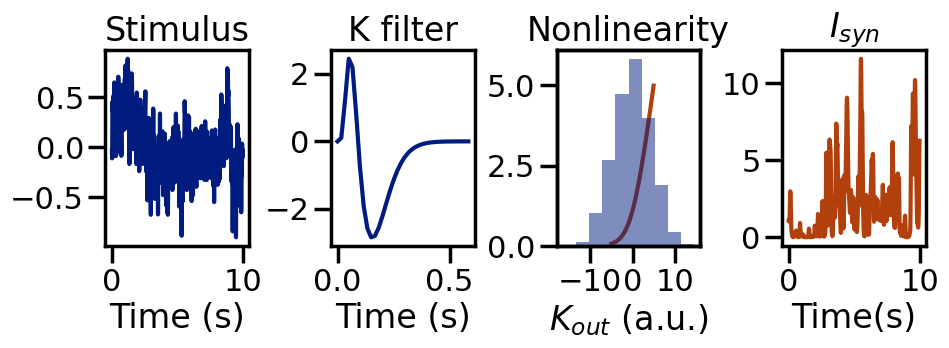

In [10]:
t_k = jnp.arange(len(rates[0]))/frame_rate
sns.set_palette("dark")
fig, axes = plt.subplots(1, 4, figsize=(10, 4),  layout="constrained")

axes[0].set_title("Stimulus")
axes[0].plot(t_k,stim[0])
axes[0].set_xlabel("Time (s)")
axes[1].plot(jnp.arange(len(K))*dt, K)
axes[1].set_xlabel("Time (s)")
axes[1].set_title("K filter")

axes[2].set_title("Nonlinearity")
xvals = jnp.linspace(-5, 5, 200)
nl_vals = softplus(xvals, nl_gain=BC.nl_gain, shift=BC.nl_shift, beta=BC.nl_beta)
axes[2].plot(xvals, nl_vals,c=sns.color_palette("dark")[1])
axes[2].set_ylim(0,6.1)
ax_hist = axes[2].twinx()
ax_hist.hist(L.ravel(), density=True, alpha=0.5) #all trials
# ax_hist.hist(stim.ravel(), density=True, alpha=0.6, label='Stim')
ax_hist.set_yticks([])
# ax_hist.legend()
# ax_hist.hist(L[2])
axes[2].set_xlabel(r"$K_{out}$ (a.u.)")

# axes[3].plot(t_k,L[0], label="Before NL")
axes[3].plot(t_k,rates[0], label="After NL",c=sns.color_palette("dark")[1])
axes[3].set_title(r"$I_{syn}$")
axes[3].set_title(r"$I_{syn}$")
axes[3].set_xlabel("Time(s)")

# for ax in axes:
#     ax.set_yticks([])
# axes[3].legend()
fig.tight_layout(w_pad=0.1)